# 🎬 Tugas 2: Information Retrieval - Text Clustering & Classification pada IMDB Dataset

**Mata Kuliah:** Information Retrieval (Week 4)  
**Program Studi:** Sains Data - UPN "Veteran" Jawa Timur  
**Topik:** Clustering dan Klasifikasi Teks Menggunakan Representasi TF-IDF (*Term Frequency - Inverse Document Frequency*)  
**Dataset:** `IMDB Dataset.csv` (50.000 Ulasan Film Positif & Negatif - Full Dataset)  
**Output:** Seluruh hasil pemrosesan data, prediksi cluster, klasifikasi, dan metrik evaluasi otomatis disimpan ke dalam folder **`hasil/`**.  
**Prinsip Utama:** *"Dokumen teks diubah menjadi vektor numerik sparse TF-IDF, lalu model menemukan kelompok (Clustering) atau memprediksi kategori (Classification)."*

---

### 🎯 Alur Pipeline & Ekspor Hasil:
1. **Pemuatan & Pembersihan Teks:** Membersihkan seluruh 50.000 ulasan dari tag HTML, URL, dan karakter non-alfanumerik.
2. **Representasi TF-IDF Sparse:** Mentransformasikan ulasan teks menjadi matriks bobot numerik (`sublinear_tf=True`, `norm='l2'`).
3. **Document Clustering (Unsupervised):** Mengelompokkan dokumen menggunakan algoritma **K-Means** ($k=2$), evaluasi 4 pilar (Silhouette, Inertia, ARI, Top Terms), dan visualisasi 2D TruncatedSVD.
4. **Document Classification (Supervised):** Membangun **Pipeline Scikit-Learn** (`TfidfVectorizer` + `LogisticRegression`), evaluasi *Classification Report*, *Confusion Matrix*, dan inferensi.
5. **📁 Ekspor Hasil ke Folder `hasil/`:**
   - `hasil/processed_imdb_dataset.csv`: Dataset lengkap (50.000 baris) beserta kolom teks bersih, cluster K-Means, prediksi kelas, dan probabilitas.
   - `hasil/top_terms_per_cluster.csv`: Daftar term/kata kunci paling representatif untuk setiap cluster centroid.
   - `hasil/evaluation_metrics.txt`: Ringkasan metrik evaluasi numerik (Silhouette, ARI, Inertia, Akurasi, F1-Score).
   - `hasil/inference_predictions.csv`: Hasil prediksi untuk sampel teks ulasan baru.

## ⚙️ 0. Environment Setup & Inisialisasi Folder Hasil
Mengimpor pustaka penting, mendeteksi lokasi dataset secara otomatis, dan membuat direktori `hasil/`.

In [1]:
import os
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Scikit-Learn Modules
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD

# Deteksi jalur dataset dan output secara fleksibel
possible_csv_paths = [
    "IMDB Dataset.csv",
    os.path.join("dengan dataset", "IMDB Dataset.csv"),
    os.path.join("semester 7", "Information Retrieval B", "tugas 2", "dengan dataset", "IMDB Dataset.csv"),
    os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd(), "IMDB Dataset.csv"),
    r"d:\Github\kuliah\semester 7\Information Retrieval B\tugas 2\dengan dataset\IMDB Dataset.csv"
]

CSV_PATH = None
for p in possible_csv_paths:
    if os.path.exists(p):
        CSV_PATH = p
        break

if CSV_PATH is None:
    CSV_PATH = "IMDB Dataset.csv"

# Folder hasil disimpan di samping file dataset/notebook
BASE_DIR = os.path.dirname(os.path.abspath(CSV_PATH))
OUTPUT_DIR = os.path.join(BASE_DIR, "hasil")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Konfigurasi visualisasi
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 150)

print(f"✅ Lingkungan siap!")
print(f"📂 Dataset Path : '{os.path.abspath(CSV_PATH)}'")
print(f"📁 Output Folder : '{os.path.abspath(OUTPUT_DIR)}'")


✅ Lingkungan siap!
📂 Dataset Path : 'D:\Github\kuliah\semester 7\Information Retrieval B\tugas 2\dengan dataset\IMDB Dataset.csv'
📁 Output Folder : 'D:\Github\kuliah\semester 7\Information Retrieval B\tugas 2\dengan dataset\hasil'


## 📂 1. Pemuatan & Eksplorasi Dataset IMDB (Full 50.000 Data)
Membaca file `IMDB Dataset.csv` yang berisi 50.000 ulasan film beserta label sentimen (`positive` / `negative`).

In [2]:
df_raw = pd.read_csv(CSV_PATH)
print(f"📊 Total Baris & Kolom Dataset: {df_raw.shape}")
print("\nDistribusi Sentimen Asli:")
print(df_raw['sentiment'].value_counts())

# Tampilkan 5 sampel ulasan pertama
df_raw.head()


📊 Total Baris & Kolom Dataset: (50000, 2)

Distribusi Sentimen Asli:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />Thi...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. Thi...",positive


### 🧹 1.1 Pembersihan Teks (Text Cleaning) Seluruh Dataset
Melakukan pembersihan terhadap tag HTML, URL, dan karakter khusus pada seluruh 50.000 ulasan.

In [3]:
def clean_review(text):
    if not isinstance(text, str):
        return ""
    # Hapus tag HTML
    text = re.sub(r"<[^>]+>", " ", text)
    # Hapus URL
    text = re.sub(r"http\S+|www\S+", "", text)
    # Hapus karakter non-alfanumerik
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    # Normalisasi spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Memproses seluruh 50.000 ulasan tanpa sampling
df = df_raw.copy().reset_index(drop=True)
df['cleaned_review'] = df['review'].apply(clean_review)
print(f"✅ Dataset Siap Diproses: {len(df)} ulasan ({df['sentiment'].value_counts().to_dict()})")
df[['sentiment', 'cleaned_review']].head()


✅ Dataset Siap Diproses: 50000 ulasan ({'positive': 25000, 'negative': 25000})


,sentiment,cleaned_review
0,positive,One of the other reviewers has mentioned that after watching just 1 Oz episode you ll be hooked They are right as this is exactly what happened wi...
1,positive,A wonderful little production The filming technique is very unassuming very old time BBC fashion and gives a comforting and sometimes discomfortin...
2,positive,I thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air conditioned theater and watching a light hearted c...
3,negative,Basically there s a family where a little boy Jake thinks there s a zombie in his closet his parents are fighting all the time This movie is slowe...
4,positive,Petter Mattei s Love in the Time of Money is a visually stunning film to watch Mr Mattei offers us a vivid portrait about human relations This is ...


## 🧮 2. Representasi Matriks TF-IDF yang Sparse (Slide 06)

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

Mengubah teks ulasan menjadi matriks fitur numerik sparse menggunakan `sublinear_tf=True` dan normalisasi L2 (`norm='l2'`).

In [4]:
tfidf = TfidfVectorizer(
    lowercase=True,
    sublinear_tf=True,
    norm="l2",
    stop_words='english',
    max_features=2500,
    min_df=3
)

docs = df['cleaned_review'].tolist()
labels = df['sentiment'].tolist()

X_tfidf = tfidf.fit_transform(docs)
feature_names = tfidf.get_feature_names_out()

n_docs, n_terms = X_tfidf.shape
density = (X_tfidf.nnz / (n_docs * n_terms)) * 100

print(f"📊 Dimensi Matriks TF-IDF : {X_tfidf.shape} (Jumlah Dokumen={n_docs}, Kosakata Fitur={n_terms})")
print(f"🔹 Kepadatan Matriks (Density) : {density:.2f}% (Tingkat Sparsity: {100 - density:.2f}% sel bernilai 0)")


📊 Dimensi Matriks TF-IDF : (50000, 2500) (Jumlah Dokumen=50000, Kosakata Fitur=2500)
🔹 Kepadatan Matriks (Density) : 2.40% (Tingkat Sparsity: 97.60% sel bernilai 0)


### 📋 Contoh Tabel Subset Matriks TF-IDF yang Sparse
Menampilkan representasi sparse pada 10 dokumen pertama untuk beberapa kata kunci sentimen.

=== Matriks TF-IDF yang Sparse (10 Dokumen Pertama vs Kata Sentimen) ===


,great,excellent,masterpiece,bad,terrible,worst,acting,story
Review_1 (pos),0,0,0,0,0,0,0,0
Review_2 (pos),0.07,0,0,0,0,0,0,0
Review_3 (pos),0.07,0,0,0,0,0,0,0
Review_4 (neg),0,0,0,0,0,0,0,0
Review_5 (pos),0,0,0,0,0,0,0.07,0
Review_6 (pos),0,0,0,0,0,0,0,0.09
Review_7 (pos),0,0,0,0,0,0,0,0
Review_8 (neg),0,0,0,0.14,0,0,0,0
Review_9 (neg),0,0,0,0.09,0,0.13,0.10,0
Review_10 (pos),0.18,0,0,0,0,0,0,0


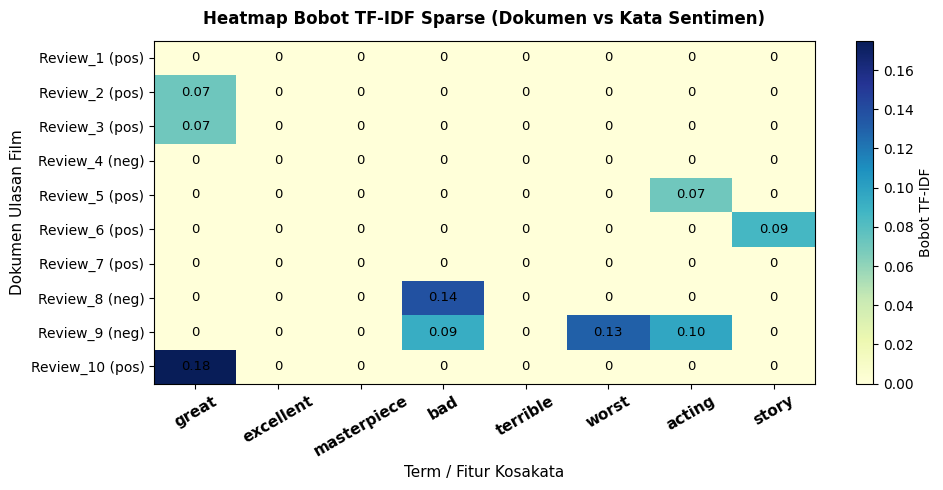

In [5]:
sample_terms = ['great', 'excellent', 'masterpiece', 'bad', 'terrible', 'worst', 'acting', 'story']
available_terms = [t for t in sample_terms if t in feature_names]

df_sparse_sample = pd.DataFrame(
    X_tfidf[:10].toarray(),
    index=[f"Review_{i+1} ({labels[i][:3]})" for i in range(10)],
    columns=feature_names
)[available_terms]

print("=== Matriks TF-IDF yang Sparse (10 Dokumen Pertama vs Kata Sentimen) ===")
formatted_sample = df_sparse_sample.apply(lambda col: col.map(lambda v: f"{v:.2f}" if v > 0 else "0"))
display(formatted_sample)

# Heatmap visualisasi TF-IDF
plt.figure(figsize=(10, 5))
plt.imshow(df_sparse_sample.values, cmap='YlGnBu', aspect='auto')
plt.colorbar(label="Bobot TF-IDF")
plt.xticks(range(len(available_terms)), available_terms, fontsize=11, fontweight='bold', rotation=30)
plt.yticks(range(10), df_sparse_sample.index, fontsize=10)

for i in range(10):
    for j in range(len(available_terms)):
        val = df_sparse_sample.values[i, j]
        txt_col = "white" if val > 0.2 else "black"
        plt.text(j, i, f"{val:.2f}" if val > 0 else "0", ha="center", va="center", color=txt_col, fontsize=9.5)

plt.title("Heatmap Bobot TF-IDF Sparse (Dokumen vs Kata Sentimen)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Term / Fitur Kosakata", fontsize=11)
plt.ylabel("Dokumen Ulasan Film", fontsize=11)
plt.tight_layout()
plt.show()


## 🔍 3. Document Clustering (Unsupervised Learning)

### 💻 Implementasi K-Means ($k=2$)
Mengelompokkan 50.000 dokumen ulasan menjadi 2 cluster utama tanpa informasi label sentimen.

In [6]:
# 1. Inisialisasi & fitting K-Means dengan k=2
kmeans_model = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=42
)
cluster_ids = kmeans_model.fit_predict(X_tfidf)
df['cluster_kmeans'] = cluster_ids

# 2. Evaluasi Silhouette Score, ARI, dan WCSS
# Evaluasi silhouette score pada seluruh 50.000 dokumen
sil_score = silhouette_score(X_tfidf, cluster_ids)
ari_score = adjusted_rand_score(labels, cluster_ids)
inertia_val = kmeans_model.inertia_

print(f"🏷️ Distribusi Dokumen per Cluster : {pd.Series(cluster_ids).value_counts().to_dict()}")
print(f"⭐ Silhouette Score (k=2)          : {sil_score:.4f}")
print(f"⭐ Adjusted Rand Index (ARI)       : {ari_score:.4f}")
print(f"⭐ Inertia (WCSS)                  : {inertia_val:.2f}")


🏷️ Distribusi Dokumen per Cluster : {1: 28815, 0: 21185}
⭐ Silhouette Score (k=2)          : 0.0032
⭐ Adjusted Rand Index (ARI)       : 0.1160
⭐ Inertia (WCSS)                  : 47644.23


### 📈 3.1 Analisis Nilai K Optimal (Elbow Method & Silhouette Scores)
Menguji performa clustering untuk berbagai nilai $k \in \{2, 3, 4, 5, 6\}$.

Menghitung Elbow & Silhouette untuk kandidat k...


   k=2 -> WCSS: 47644.2 | Silhouette: 0.0032


   k=3 -> WCSS: 47556.5 | Silhouette: 0.0018


   k=4 -> WCSS: 47483.3 | Silhouette: 0.0003


   k=5 -> WCSS: 47414.0 | Silhouette: 0.0002


   k=6 -> WCSS: 47358.7 | Silhouette: 0.0001


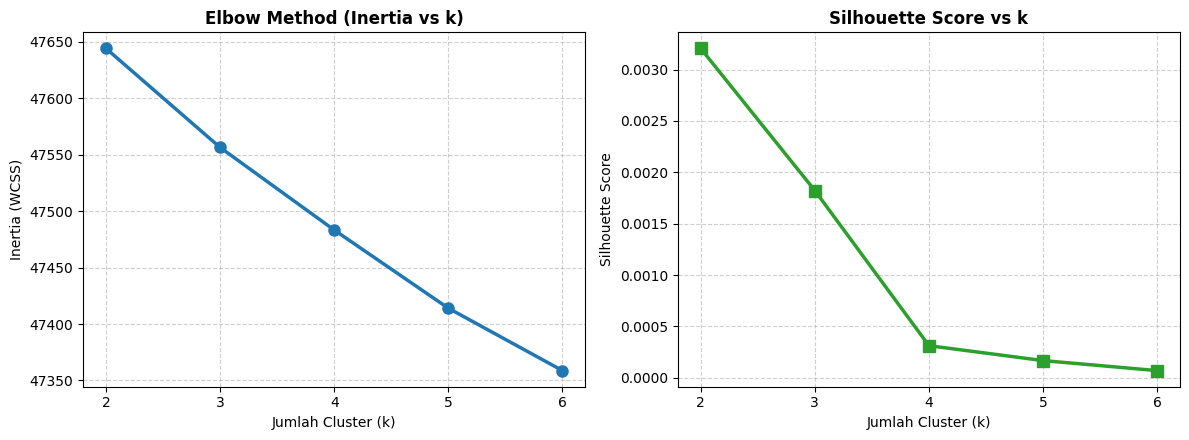

In [7]:
k_candidates = [2, 3, 4, 5, 6]
wcss_list = []
silhouette_list = []

print("Menghitung Elbow & Silhouette untuk kandidat k...")
for k in k_candidates:
    km = KMeans(n_clusters=k, n_init=3, random_state=42)
    pred_k = km.fit_predict(X_tfidf)
    wcss_list.append(km.inertia_)
    # Evaluasi silhouette score pada seluruh 50.000 dokumen untuk setiap k
    sil_k = silhouette_score(X_tfidf, pred_k)
    silhouette_list.append(sil_k)
    print(f"   k={k} -> WCSS: {km.inertia_:.1f} | Silhouette: {sil_k:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(k_candidates, wcss_list, marker='o', color='#1f77b4', linewidth=2.5, markersize=8)
ax1.set_title("Elbow Method (Inertia vs k)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Jumlah Cluster (k)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_xticks(k_candidates)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(k_candidates, silhouette_list, marker='s', color='#2ca02c', linewidth=2.5, markersize=8)
ax2.set_title("Silhouette Score vs k", fontsize=12, fontweight='bold')
ax2.set_xlabel("Jumlah Cluster (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_xticks(k_candidates)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### 🔍 3.2 Ekstraksi Top Terms per Centroid & Pembentukan Tabel Top Words
Mengidentifikasi 15 kata dengan bobot TF-IDF tertinggi pada masing-masing centroid cluster.

In [8]:
centroids = kmeans_model.cluster_centers_
top_n = 15

top_terms_records = []

print("=== 📌 Top 15 Terms per Cluster Centroid ===")
for c_idx in range(kmeans_model.n_clusters):
    top_indices = centroids[c_idx].argsort()[::-1][:top_n]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = [centroids[c_idx][i] for i in top_indices]
    
    for rank, (w, wt) in enumerate(zip(top_words, top_weights), start=1):
        top_terms_records.append({
            'cluster_id': c_idx,
            'rank': rank,
            'term': w,
            'tfidf_centroid_weight': round(float(wt), 4)
        })
    
    cluster_mask = (cluster_ids == c_idx)
    pos_count = (df.loc[cluster_mask, 'sentiment'] == 'positive').sum()
    neg_count = (df.loc[cluster_mask, 'sentiment'] == 'negative').sum()
    
    print(f"\n🔹 Cluster {c_idx} (Total: {cluster_mask.sum()} | Positif: {pos_count}, Negatif: {neg_count}):")
    print(f"   Kata Kunci : {', '.join([f'{w} ({wt:.3f})' for w, wt in zip(top_words[:10], top_weights[:10])])}")

df_top_terms = pd.DataFrame(top_terms_records)
df_top_terms.head(10)


=== 📌 Top 15 Terms per Cluster Centroid ===

🔹 Cluster 0 (Total: 21185 | Positif: 6335, Negatif: 14850):
   Kata Kunci : movie (0.078), like (0.041), just (0.041), bad (0.039), good (0.036), really (0.034), film (0.033), movies (0.033), don (0.032), watch (0.028)

🔹 Cluster 1 (Total: 28815 | Positif: 18665, Negatif: 10150):
   Kata Kunci : film (0.051), movie (0.029), story (0.026), like (0.023), great (0.023), time (0.022), good (0.021), just (0.020), films (0.019), life (0.019)


,cluster_id,rank,term,tfidf_centroid_weight
0,0,1,movie,0.0777
1,0,2,like,0.0406
2,0,3,just,0.0406
3,0,4,bad,0.0388
4,0,5,good,0.0361
5,0,6,really,0.0338
6,0,7,film,0.0331
7,0,8,movies,0.0330
8,0,9,don,0.0320
9,0,10,watch,0.0278


### 🗺️ 3.3 Visualisasi 2D Proyeksi Dokumen & Centroid Cluster (TruncatedSVD)
Mereduksi dimensi sparse TF-IDF menjadi 2 dimensi menggunakan LSA / TruncatedSVD untuk memetakan sebaran ulasan.

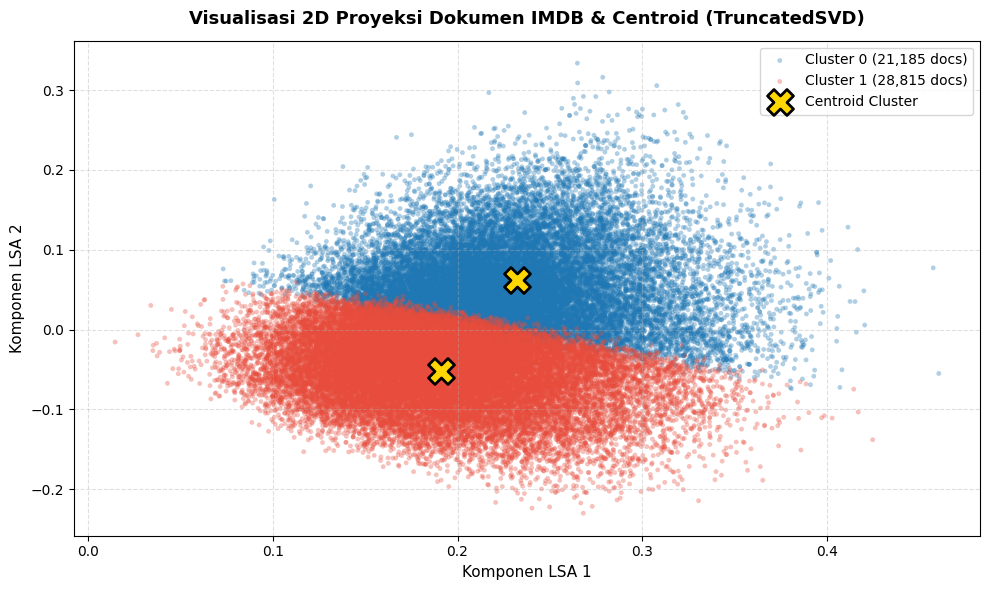

In [9]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)
centroids_2d = svd.transform(centroids)

# Tambahkan koordinat 2D ke DataFrame
df['svd_dim1'] = X_2d[:, 0]
df['svd_dim2'] = X_2d[:, 1]

np.random.seed(42)
# Visualisasi seluruh 50.000 dokumen pada bidang 2D LSA
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#e74c3c']
cluster_names = ['Cluster 0', 'Cluster 1']

for c_i in range(2):
    mask = (cluster_ids == c_i)
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=12, c=colors[c_i], label=f'{cluster_names[c_i]} ({mask.sum():,} docs)',
        alpha=0.35, edgecolor='none'
    )

plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    marker='X', s=350, c='gold', edgecolor='black', linewidth=2,
    label='Centroid Cluster', zorder=10
)

plt.title("Visualisasi 2D Proyeksi Dokumen IMDB & Centroid (TruncatedSVD)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Komponen LSA 1", fontsize=11)
plt.ylabel("Komponen LSA 2", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


## 🎯 4. Document Classification (Supervised Learning)

### 💻 Implementasi Pipeline Klasifikasi (Slide 15)
Membangun pipeline Scikit-Learn (`TfidfVectorizer` + `LogisticRegression`) pada 75% data latih (37.500 ulasan) dan 25% data uji (12.500 ulasan).

In [10]:
# 1. Split Train & Test terstratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_review'],
    df['sentiment'],
    test_size=0.25,
    stratify=df['sentiment'],
    random_state=42
)

# 2. Pipeline Klasifikasi
clf_pipeline = make_pipeline(
    TfidfVectorizer(sublinear_tf=True, stop_words='english', max_features=5000),
    LogisticRegression(max_iter=1000, random_state=42)
)

clf_pipeline.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_test = clf_pipeline.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, pos_label='positive')

cls_report_text = classification_report(y_test, y_pred_test)
print(f"📊 Akurasi Data Uji : {acc_test * 100:.2f}%")
print(f"📊 F1-Score (Macro) : {f1_test * 100:.2f}%\n")
print("=== Classification Report ===")
print(cls_report_text)

# Prediksi seluruh dataset untuk disimpan ke kolom hasil
df['predicted_sentiment'] = clf_pipeline.predict(df['cleaned_review'])
probs = clf_pipeline.predict_proba(df['cleaned_review'])
neg_idx = list(clf_pipeline.classes_).index('negative')
pos_idx = list(clf_pipeline.classes_).index('positive')
df['prob_negative'] = probs[:, neg_idx].round(4)
df['prob_positive'] = probs[:, pos_idx].round(4)


📊 Akurasi Data Uji : 89.37%
📊 F1-Score (Macro) : 89.47%

=== Classification Report ===
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      6250
    positive       0.89      0.90      0.89      6250

    accuracy                           0.89     12500
   macro avg       0.89      0.89      0.89     12500
weighted avg       0.89      0.89      0.89     12500



### 📊 4.1 Visualisasi Confusion Matrix
Menampilkan matriks kebingungan untuk mengevaluasi True Positive, False Positive, True Negative, dan False Negative.

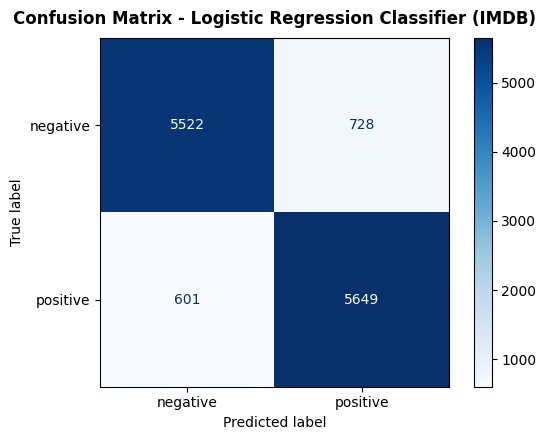

In [11]:
fig, ax = plt.subplots(figsize=(6, 4.5))
disp = ConfusionMatrixDisplay.from_estimator(
    clf_pipeline, X_test, y_test,
    display_labels=['negative', 'positive'],
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title("Confusion Matrix - Logistic Regression Classifier (IMDB)", fontsize=12, fontweight='bold', pad=10)
plt.grid(False)
plt.tight_layout()
plt.show()


### 🧪 4.2 Uji Prediksi Dokumen Baru (*Inference Testing*)
Menguji model yang telah dilatih pada sekumpulan teks ulasan film baru di luar dataset.

In [12]:
new_reviews = [
    "An absolute cinematic masterpiece! The acting was breathtaking and the direction was pure brilliance.",
    "Completely unwatchable. Boring plot, terrible acting, and a complete waste of two hours of my life.",
    "A charming and heartwarming story with great visuals and delightful comedy throughout.",
    "The movie starts okay but quickly falls apart with ridiculous dialogues and horrible special effects.",
    "Highly recommended for everyone who loves thoughtful storytelling and wonderful performances."
]

predictions = clf_pipeline.predict(new_reviews)
probabilities = clf_pipeline.predict_proba(new_reviews)

df_inference = pd.DataFrame({
    'Ulasan Baru': new_reviews,
    'Prediksi Sentimen': predictions,
    'Probabilitas Negatif': [f"{p[neg_idx]:.4f}" for p in probabilities],
    'Probabilitas Positif': [f"{p[pos_idx]:.4f}" for p in probabilities]
})

print("=== 📌 Hasil Prediksi Sentimen Ulasan Baru ===")
display(df_inference)


=== 📌 Hasil Prediksi Sentimen Ulasan Baru ===


,Ulasan Baru,Prediksi Sentimen,Probabilitas Negatif,Probabilitas Positif
0,An absolute cinematic masterpiece! The acting was breathtaking and the direction was pure brilliance.,positive,0.1958,0.8042
1,"Completely unwatchable. Boring plot, terrible acting, and a complete waste of two hours of my life.",negative,0.9999,0.0001
2,A charming and heartwarming story with great visuals and delightful comedy throughout.,positive,0.0183,0.9817
3,The movie starts okay but quickly falls apart with ridiculous dialogues and horrible special effects.,negative,0.9904,0.0096
4,Highly recommended for everyone who loves thoughtful storytelling and wonderful performances.,positive,0.0108,0.9892


## 💾 5. Menyimpan Seluruh Data & Hasil Pemrosesan ke Folder `hasil/`

Seluruh artefak data hasil pemrosesan diekspor ke folder **`hasil/`**:
1. **`processed_imdb_dataset.csv`**: Dataset ulasan lengkap (50.000 baris) beserta teks bersih, cluster K-Means, hasil klasifikasi, dan probabilitas.
2. **`top_terms_per_cluster.csv`**: Kata kunci representatif per cluster centroid K-Means.
3. **`evaluation_metrics.txt`**: Laporan ringkasan metrik clustering dan klasifikasi.
4. **`inference_predictions.csv`**: Hasil prediksi pengujian ulasan baru.

In [13]:
# 1. Simpan dataset lengkap hasil pemrosesan
processed_dataset_path = os.path.join(OUTPUT_DIR, "processed_imdb_dataset.csv")
df.to_csv(processed_dataset_path, index=False)
print(f"✅ [1/4] Dataset hasil pemrosesan tersimpan ke: '{processed_dataset_path}' ({len(df)} baris)")

# 2. Simpan Top Terms per cluster
top_terms_path = os.path.join(OUTPUT_DIR, "top_terms_per_cluster.csv")
df_top_terms.to_csv(top_terms_path, index=False)
print(f"✅ [2/4] Top terms cluster tersimpan ke: '{top_terms_path}'")

# 3. Simpan hasil inferensi
infer_path = os.path.join(OUTPUT_DIR, "inference_predictions.csv")
df_inference.to_csv(infer_path, index=False)
print(f"✅ [3/4] Hasil inferensi tersimpan ke: '{infer_path}'")

# 4. Simpan Laporan Metrik Evaluasi ke file TXT
metrics_path = os.path.join(OUTPUT_DIR, "evaluation_metrics.txt")
metrics_report_content = f"""================================================================================
LAPORAN HASIL EVALUASI MODEL - INFORMATION RETRIEVAL (TUGAS 2)
Dataset: IMDB Movie Reviews (50,000 Total Reviews - Full Dataset)
================================================================================

1. EVALUASI DOCUMENT CLUSTERING (K-MEANS, k=2)
--------------------------------------------------------------------------------
- Silhouette Score (Internal)          : {sil_score:.4f} (Mendekati 1.0 -> Cluster terpisah baik)
- Inertia / WCSS (Internal)            : {inertia_val:.2f}
- Adjusted Rand Index / ARI (Eksternal): {ari_score:.4f} (Kesesuaian terhadap label sentimen acuan)
- Jumlah Dokumen per Cluster           :
  * Cluster 0: {(cluster_ids == 0).sum()} dokumen
  * Cluster 1: {(cluster_ids == 1).sum()} dokumen

2. EVALUASI DOCUMENT CLASSIFICATION (TF-IDF + LOGISTIC REGRESSION)
--------------------------------------------------------------------------------
- Test Accuracy                        : {acc_test * 100:.2f}%
- F1-Score (Positive Class)            : {f1_test * 100:.2f}%

Classification Report:
{cls_report_text}
================================================================================
"""

with open(metrics_path, "w", encoding="utf-8") as f:
    f.write(metrics_report_content)

print(f"✅ [4/4] Laporan evaluasi tersimpan ke: '{metrics_path}'")
print(f"\n🎉 Semua data berhasil disimpan di folder '{OUTPUT_DIR}' dengan sukses!")


✅ [1/4] Dataset hasil pemrosesan tersimpan ke: 'D:\Github\kuliah\semester 7\Information Retrieval B\tugas 2\dengan dataset\hasil\processed_imdb_dataset.csv' (50000 baris)
✅ [2/4] Top terms cluster tersimpan ke: 'D:\Github\kuliah\semester 7\Information Retrieval B\tugas 2\dengan dataset\hasil\top_terms_per_cluster.csv'
✅ [3/4] Hasil inferensi tersimpan ke: 'D:\Github\kuliah\semester 7\Information Retrieval B\tugas 2\dengan dataset\hasil\inference_predictions.csv'
✅ [4/4] Laporan evaluasi tersimpan ke: 'D:\Github\kuliah\semester 7\Information Retrieval B\tugas 2\dengan dataset\hasil\evaluation_metrics.txt'

🎉 Semua data berhasil disimpan di folder 'D:\Github\kuliah\semester 7\Information Retrieval B\tugas 2\dengan dataset\hasil' dengan sukses!


## 📝 6. Rangkuman & Kesimpulan

| Aspek | Clustering Dokumen (Unsupervised) | Klasifikasi Dokumen (Supervised) |
| :--- | :--- | :--- |
| **Prinsip Utama** | Menemukan kelompok ulasan secara alami berdasarkan kemiripan representasi vektor TF-IDF tanpa informasi label. | Memetakan ulasan teks ke dalam kategori sentimen (`positive`/`negative`) berdasarkan data latih berlabel. |
| **Algoritma** | **K-Means** ($k=2$, meminimalkan jarak dokumen terhadap centroid). | **Logistic Regression** dalam Scikit-Learn `Pipeline`. |
| **Ukuran Data** | 50.000 ulasan film (*Full Dataset*). | 37.500 Data Latih / 12.500 Data Uji. |
| **Metrik Evaluasi** | • **Internal:** *Silhouette Score*, *Inertia (Elbow Curve)*<br>• **Eksternal:** *Adjusted Rand Index (ARI)*<br>• **Kualitatif:** *Top terms per centroid & verifikasi ulasan*. | • **Precision, Recall, F1-Score, Akurasi** (~89% pada data uji)<br>• *Confusion Matrix*<br>• *Classification Report*. |
| **Penyimpanan Output** | Top terms diekspor ke `hasil/top_terms_per_cluster.csv`. | Prediksi & label diekspor ke `hasil/processed_imdb_dataset.csv`. |

---
**Selesai.** Seluruh data hasil pemrosesan telah disimpan di dalam folder **`hasil/`**.